# Data validation and exploratory analysis

This notebook validates the transaction dataset, quantifies the class imbalance, and examines amount and time patterns before any model is trained.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid")
DATA_PATH = next(
    (
        root / "data/raw/creditcard.csv"
        for root in (Path.cwd(), *Path.cwd().parents)
        if (root / "data/raw/creditcard.csv").exists()
    ),
    None,
)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Download creditcard.csv as described in the README and place it in data/raw/."
    )

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
df.head()

Matplotlib is building the font cache; this may take a moment.


Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
expected_columns = (
    ["Time"]
    + [f"V{i}" for i in range(1, 29)]
    + ["Amount", "Class"]
)

assert list(df.columns) == expected_columns
assert set(df["Class"].unique()) == {0, 1}
assert df.isna().sum().sum() == 0
assert (df["Amount"] >= 0).all()

print("All initial data-validation checks passed.")

All initial data-validation checks passed.


In [3]:
class_counts = df["Class"].value_counts().sort_index()
class_rates = df["Class"].value_counts(normalize=True).sort_index()

class_summary = pd.DataFrame(
    {
        "count": class_counts,
        "percentage": class_rates * 100,
    }
)

class_summary.index = ["Legitimate", "Fraud"]
class_summary

,count,percentage
Legitimate,284315,99.827251
Fraud,492,0.172749


## initial findings 

## Initial findings

Fraud occurs in approximately 0.17% of transactions. Accuracy is therefore not used as a primary metric: predicting every transaction as legitimate would achieve approximately 99.83% accuracy while detecting no fraud.

In [4]:
df.info()
df[["Time", "Amount"]].describe()
duplicate_count = df.duplicated().sum()
duplicate_percentage = duplicate_count / len(df) * 100

print(f"Duplicate rows: {duplicate_count:,}")
print(f"Duplicate percentage: {duplicate_percentage:.3f}%")

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

Duplicate rows: 1,081
Duplicate percentage: 0.380%


### Duplicate handling

The 1,081 exact duplicate rows are retained because the anonymized fields do not reveal whether they are repeated records or distinct transactions with identical observed attributes. A cross-split check found no exact-row overlap between training and validation or between the combined development period and test, so retained duplicates do not leak identical observations across evaluation boundaries.

In [5]:
amount_summary = (
    df.groupby("Class")["Amount"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .rename(index={0: "Legitimate", 1: "Fraud"})
)

amount_summary

,count,mean,median,std,min,max
Class,,,,,,
Legitimate,284315,88.291022,22.00,250.105092,0.0,25691.16
Fraud,492,122.211321,9.25,256.683288,0.0,2125.87


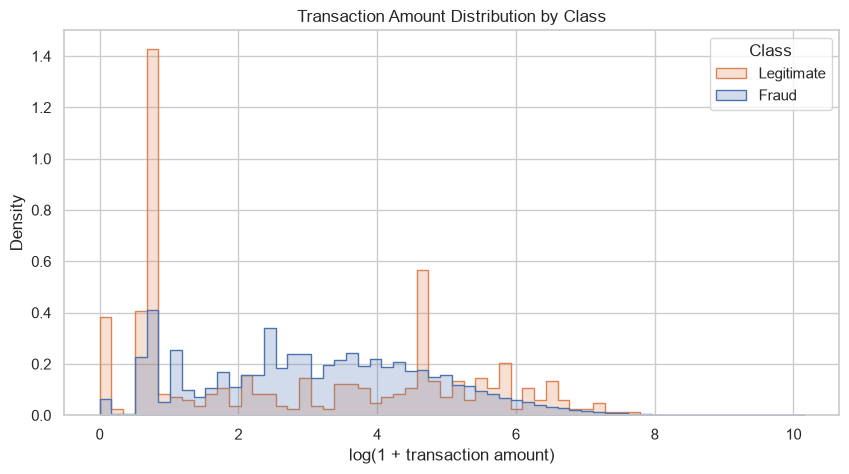

In [6]:
plot_df = df.assign(LogAmount=np.log1p(df["Amount"]))

plt.figure(figsize=(10, 5))

sns.histplot(
    data=plot_df,
    x="LogAmount",
    hue="Class",
    bins=60,
    stat="density",
    common_norm=False,
    element="step",
)

plt.title("Transaction Amount Distribution by Class")
plt.xlabel("log(1 + transaction amount)")
plt.ylabel("Density")
plt.legend(title="Class", labels=["Legitimate", "Fraud"])
plt.show()

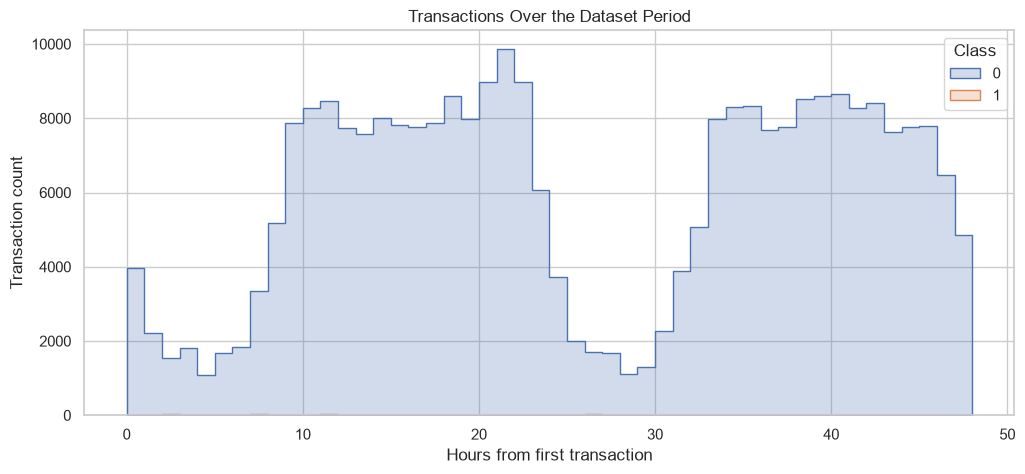

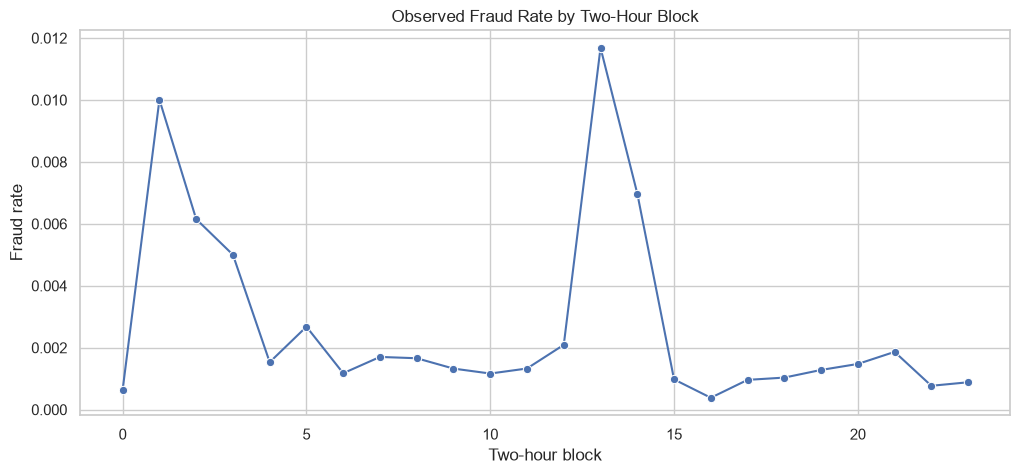

In [7]:
df["HourFromStart"] = df["Time"] / 3600
plt.figure(figsize=(12, 5))

sns.histplot(
    data=df,
    x="HourFromStart",
    hue="Class",
    bins=48,
    multiple="layer",
    element="step",
    common_norm=False,
)

plt.title("Transactions Over the Dataset Period")
plt.xlabel("Hours from first transaction")
plt.ylabel("Transaction count")
plt.show()

df["TimeBlock"] = (df["HourFromStart"] // 2).astype(int)

fraud_by_time = (
    df.groupby("TimeBlock")
    .agg(
        transactions=("Class", "size"),
        fraud_count=("Class", "sum"),
        fraud_rate=("Class", "mean"),
    )
    .reset_index()
)

fraud_by_time.head()

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=fraud_by_time,
    x="TimeBlock",
    y="fraud_rate",
    marker="o",
)

plt.title("Observed Fraud Rate by Two-Hour Block")
plt.xlabel("Two-hour block")
plt.ylabel("Fraud rate")
plt.show()

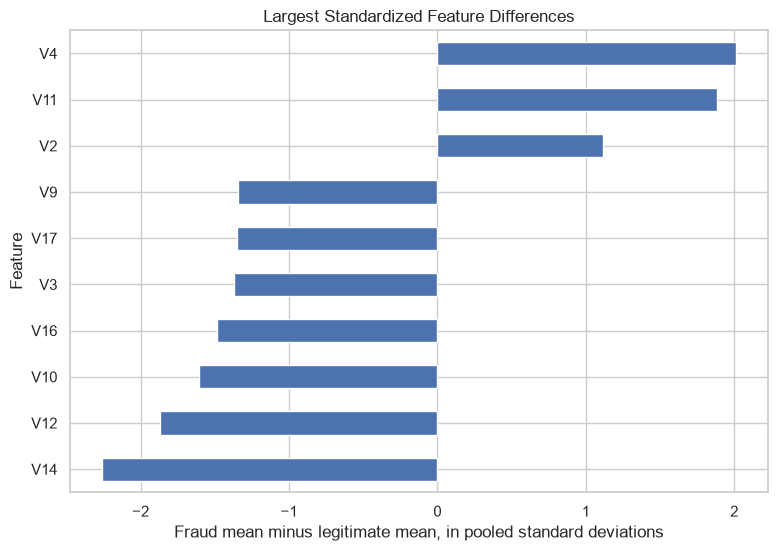

In [8]:
v_columns = [f"V{i}" for i in range(1, 29)]

legitimate = df.loc[df["Class"] == 0, v_columns]
fraud = df.loc[df["Class"] == 1, v_columns]

pooled_std = np.sqrt(
    (legitimate.var() + fraud.var()) / 2
)

standardized_difference = (
    (fraud.mean() - legitimate.mean()) / pooled_std
).sort_values(key=abs, ascending=False)

standardized_difference.head(10)

top_features = standardized_difference.head(10).sort_values()

plt.figure(figsize=(9, 6))
top_features.plot(kind="barh")

plt.title("Largest Standardized Feature Differences")
plt.xlabel("Fraud mean minus legitimate mean, in pooled standard deviations")
plt.ylabel("Feature")
plt.show()